## Install and imports

In [1]:
# Uncomment only if needed.
# !pip install -q flax optax orbax-checkpoint tiktoken

import os
import time
import math
import json
import shutil
from pathlib import Path

# Must be set before first JAX compilation
os.environ["JAX_COMPILATION_CACHE_DIR"] = "/kaggle/working/jax_cache"

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import optax
import tiktoken
import flax.nnx as nnx
import orbax.checkpoint as ocp
import matplotlib.pyplot as plt

## Paths and Config

In [2]:
# Dataset paths
train_data_path = "/kaggle/input/datasets/thedevastator/tinystories-narrative-classification/train.csv"
valid_data_path = "/kaggle/input/datasets/thedevastator/tinystories-narrative-classification/validation.csv"

# Output paths
WORKDIR = Path("/kaggle/working")
TOKEN_CACHE_DIR = WORKDIR / "token_cache"
TOKEN_CACHE_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = WORKDIR / "mini_gpt_jax_ckpt"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Training config

In [3]:
MAX_TRAIN_STORIES = 200_000
MAX_VALID_STORIES = 10_000

NUM_EPOCHS = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_FRAC = 0.1
GRAD_CLIP_NORM = 1.0
SEED = 42

In [4]:
BATCH_SIZE = 32
EMBED_DIM = 192
NUM_LAYERS = 6
MAX_LEN = 128
NUM_HEADS = 6

## Model config

In [5]:
VOCAB_NAME = "gpt2"
MLP_DIM = 4 * EMBED_DIM
DROPOUT_RATE = 0.0  # keep 0.0 for a simple fast Kaggle demo

# Mixed precision
PARAM_DTYPE = jnp.float32
COMPUTE_DTYPE = jnp.bfloat16  # if unstable on your runtime, switch to jnp.float32

## Load Data

In [6]:
train_df = pd.read_csv(train_data_path).dropna()
valid_df = pd.read_csv(valid_data_path).dropna()

print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)

train_stories = train_df["text"].astype(str).tolist()[:MAX_TRAIN_STORIES]
valid_stories = valid_df["text"].astype(str).tolist()[:MAX_VALID_STORIES]

print(f"Using {len(train_stories):,} train stories")
print(f"Using {len(valid_stories):,} valid stories")

train_df: (2119489, 1)
valid_df: (21990, 1)
Using 200,000 train stories
Using 10,000 valid stories


## Tokenizer and Preprocessing

In [7]:
tokenizer = tiktoken.get_encoding(VOCAB_NAME)
VOCAB_SIZE = tokenizer.n_vocab

EOT_ID = tokenizer.encode(
    "<|endoftext|>",
    allowed_special={"<|endoftext|>"}
)[0]

PAD_ID = 0  # keep simple; your old notebook already used 0-padding

print("VOCAB_SIZE:", VOCAB_SIZE)
print("EOT_ID:", EOT_ID)

VOCAB_SIZE: 50257
EOT_ID: 50256


In [8]:
def encode_story_fixed(text: str, max_len: int, tokenizer, eot_id: int):
    """
    Encode one story into fixed-length token ids.
    Returns np.uint16 array of shape [max_len].
    """
    ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    ids = ids[: max_len - 1]          # reserve one slot for EOT
    ids.append(eot_id)

    arr = np.full((max_len,), PAD_ID, dtype=np.uint16)
    arr[:len(ids)] = np.asarray(ids, dtype=np.uint16)
    return arr

In [9]:
def build_or_load_token_cache(
    stories,
    split_name: str,
    max_len: int,
    tokenizer,
    eot_id: int,
):
    token_file = TOKEN_CACHE_DIR / f"{split_name}_tokens_{len(stories)}_{max_len}.npy"

    if token_file.exists():
        print(f"Loading cached tokens from {token_file}")
        tokens = np.load(token_file, mmap_mode="r")
        return tokens, token_file

    print(f"Pretokenizing {split_name} stories...")
    start = time.time()

    arr = np.empty((len(stories), max_len), dtype=np.uint16)
    for i, story in enumerate(stories):
        arr[i] = encode_story_fixed(story, max_len, tokenizer, eot_id)
        if (i + 1) % 20000 == 0:
            print(f"  processed {i + 1:,}/{len(stories):,}")

    np.save(token_file, arr)
    elapsed = time.time() - start
    print(f"Saved token cache: {token_file}")
    print(f"Pretokenization time: {elapsed:.1f} sec")

    tokens = np.load(token_file, mmap_mode="r")
    return tokens, token_file

In [10]:
train_tokens, train_token_file = build_or_load_token_cache(
    train_stories, "train", MAX_LEN, tokenizer, EOT_ID
)

valid_tokens, valid_token_file = build_or_load_token_cache(
    valid_stories, "valid", MAX_LEN, tokenizer, EOT_ID
)

print("train_tokens shape:", train_tokens.shape, train_tokens.dtype)
print("valid_tokens shape:", valid_tokens.shape, valid_tokens.dtype)

Pretokenizing train stories...
  processed 20,000/200,000
  processed 40,000/200,000
  processed 60,000/200,000
  processed 80,000/200,000
  processed 100,000/200,000
  processed 120,000/200,000
  processed 140,000/200,000
  processed 160,000/200,000
  processed 180,000/200,000
  processed 200,000/200,000
Saved token cache: /kaggle/working/token_cache/train_tokens_200000_128.npy
Pretokenization time: 19.9 sec
Pretokenizing valid stories...
Saved token cache: /kaggle/working/token_cache/valid_tokens_10000_128.npy
Pretokenization time: 0.9 sec
train_tokens shape: (200000, 128) uint16
valid_tokens shape: (10000, 128) uint16


## Batch Iterator

In [11]:
def batch_iterator(token_array, batch_size, shuffle=True, seed=42):
    """
    token_array: shape [N, T], memory-mapped or ndarray
    yields:
      x: [B, T]
      y: [B, T]
    """
    n = len(token_array)
    idx = np.arange(n)

    rng = np.random.default_rng(seed)
    if shuffle:
        rng.shuffle(idx)

    for start in range(0, n - batch_size + 1, batch_size):
        batch_idx = idx[start:start + batch_size]
        x = np.asarray(token_array[batch_idx], dtype=np.int32)

        y = np.full_like(x, PAD_ID, dtype=np.int32)
        y[:, :-1] = x[:, 1:]
        y[:, -1] = PAD_ID

        yield x, y

In [12]:
class CausalSelfAttention(nnx.Module):
    def __init__(self, embed_dim, num_heads, *, rngs):
        self.attn = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=embed_dim,
            qkv_features=embed_dim,
            out_features=embed_dim,
            decode=False,
            rngs=rngs,
        )

    def __call__(self, x, mask=None):
        return self.attn(x, mask=mask)

In [13]:
class MLP(nnx.Module):
    def __init__(self, embed_dim, mlp_dim, *, rngs):
        self.fc1 = nnx.Linear(embed_dim, mlp_dim, rngs=rngs)
        self.fc2 = nnx.Linear(mlp_dim, embed_dim, rngs=rngs)

    def __call__(self, x):
        x = self.fc1(x)
        x = jax.nn.gelu(x)
        x = self.fc2(x)
        return x

In [14]:
class TransformerBlock(nnx.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, *, rngs):
        self.ln1 = nnx.LayerNorm(embed_dim, rngs=rngs)
        self.attn = CausalSelfAttention(embed_dim, num_heads, rngs=rngs)
        self.ln2 = nnx.LayerNorm(embed_dim, rngs=rngs)
        self.mlp = MLP(embed_dim, mlp_dim, rngs=rngs)

    def __call__(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask=mask)
        x = x + self.mlp(self.ln2(x))
        return x

In [15]:
class TokenAndPositionEmbedding(nnx.Module):
    def __init__(self, max_len, vocab_size, embed_dim, *, rngs):
        self.token_emb = nnx.Embed(vocab_size, embed_dim, rngs=rngs)
        self.pos_emb = nnx.Embed(max_len, embed_dim, rngs=rngs)
        self.max_len = max_len

    def __call__(self, token_ids):
        seq_len = token_ids.shape[1]
        positions = jnp.arange(seq_len)[None, :]
        return self.token_emb(token_ids) + self.pos_emb(positions)

## Mini GPT

In [16]:
class MiniGPT(nnx.Module):
    def __init__(
        self,
        max_len,
        vocab_size,
        embed_dim,
        num_heads,
        mlp_dim,
        num_layers,
        *,
        rngs
    ):
        self.max_len = max_len
        self.vocab_size = vocab_size

        self.embedding = TokenAndPositionEmbedding(
            max_len=max_len,
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            rngs=rngs,
        )

        self.blocks = [
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                rngs=rngs,
            )
            for _ in range(num_layers)
        ]

        self.ln_f = nnx.LayerNorm(embed_dim, rngs=rngs)
        self.lm_head = nnx.Linear(embed_dim, vocab_size, use_bias=False, rngs=rngs)

    def causal_attention_mask(self, seq_len):
        # shape [1, 1, T, T] often works nicely for attention broadcasting
        mask = jnp.tril(jnp.ones((seq_len, seq_len), dtype=jnp.bool_))
        return mask[None, None, :, :]

    def __call__(self, token_ids):
        seq_len = token_ids.shape[1]
        mask = self.causal_attention_mask(seq_len)

        x = self.embedding(token_ids)
        for block in self.blocks:
            x = block(x, mask=mask)

        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

In [17]:
rngs = nnx.Rngs(SEED)

model = MiniGPT(
    max_len=MAX_LEN,
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM,
    num_layers=NUM_LAYERS,
    rngs=rngs,
)

steps_per_epoch = len(train_tokens) // BATCH_SIZE
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = max(1, int(WARMUP_FRAC * total_steps))

print("steps_per_epoch:", steps_per_epoch)
print("total_steps:", total_steps)
print("warmup_steps:", warmup_steps)

steps_per_epoch: 6250
total_steps: 93750
warmup_steps: 9375


In [18]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=LEARNING_RATE,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5,
)

tx = optax.chain(
    optax.clip_by_global_norm(GRAD_CLIP_NORM),
    optax.adamw(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY),
)

optimizer = nnx.ModelAndOptimizer(model, tx)

## Define Loss

In [19]:
def cross_entropy_loss(logits, labels):
    """
    logits: [B, T, V]
    labels: [B, T]
    """
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
    return loss.mean()

In [20]:
@nnx.jit(donate_argnames=("model", "optimizer"))
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        logits = model(x)
        loss = cross_entropy_loss(logits, y)
        return loss

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)
    return loss

In [21]:
@nnx.jit
def eval_step(model, x, y):
    logits = model(x)
    loss = cross_entropy_loss(logits, y)
    return loss

## Text Generation

In [22]:
def generate_text(model, prompt, max_new_tokens=80, temperature=1.0, top_k=40):
    token_ids = tokenizer.encode(prompt, allowed_special={"<|endoftext|>"})
    token_ids = token_ids[:MAX_LEN]

    for _ in range(max_new_tokens):
        context = token_ids[-MAX_LEN:]
        x = np.full((1, MAX_LEN), PAD_ID, dtype=np.int32)
        x[0, :len(context)] = np.asarray(context, dtype=np.int32)

        logits = model(jnp.asarray(x))
        next_logits = logits[0, len(context) - 1] / max(temperature, 1e-6)

        if top_k is not None and top_k < next_logits.shape[-1]:
            top_vals, top_idx = jax.lax.top_k(next_logits, top_k)
            probs = jax.nn.softmax(top_vals)
            sampled_local = int(jax.random.categorical(jax.random.PRNGKey(len(token_ids)), jnp.log(probs)))
            next_token = int(top_idx[sampled_local])
        else:
            probs = jax.nn.softmax(next_logits)
            next_token = int(jax.random.categorical(jax.random.PRNGKey(len(token_ids)), jnp.log(probs)))

        token_ids.append(next_token)

        if next_token == EOT_ID:
            break

    return tokenizer.decode(token_ids)

## Training Loop

In [23]:
history = {
    "train_loss": [],
    "valid_loss": [],
    "tokens_per_sec": [],
    "step_time_sec": [],
}

global_step = 0
best_valid_loss = float("inf")

In [24]:
def run_validation(model, valid_tokens, batch_size, max_batches=100):
    losses = []

    for i, (x_np, y_np) in enumerate(batch_iterator(valid_tokens, batch_size, shuffle=False, seed=SEED)):
        x = jnp.asarray(x_np)
        y = jnp.asarray(y_np)
        loss = eval_step(model, x, y)
        losses.append(float(loss))
        if i + 1 >= max_batches:
            break

    return float(np.mean(losses)) if losses else float("nan")

In [25]:
for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    running_loss = 0.0
    running_steps = 0

    # different seed each epoch for shuffle
    train_iter = batch_iterator(
        train_tokens,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED + epoch
    )

    for step, (x_np, y_np) in enumerate(train_iter, start=1):
        step_start = time.time()

        x = jnp.asarray(x_np)
        y = jnp.asarray(y_np)

        loss = train_step(model, optimizer, x, y)

        # force sync for accurate timing
        loss_value = float(loss)
        step_time = time.time() - step_start

        tokens_this_step = x_np.size
        tok_per_sec = tokens_this_step / max(step_time, 1e-8)

        running_loss += loss_value
        running_steps += 1
        global_step += 1

        history["step_time_sec"].append(step_time)
        history["tokens_per_sec"].append(tok_per_sec)

        if step % 100 == 0:
            avg_loss = running_loss / running_steps
            current_lr = float(lr_schedule(global_step - 1))
            print(
                f"epoch={epoch+1} step={step}/{steps_per_epoch} "
                f"global_step={global_step} "
                f"loss={avg_loss:.4f} "
                f"lr={current_lr:.2e} "
                f"tok/s={tok_per_sec:,.0f} "
                f"step_time={step_time:.3f}s"
            )

    train_epoch_loss = running_loss / max(running_steps, 1)
    valid_loss = run_validation(model, valid_tokens, BATCH_SIZE, max_batches=50)

    history["train_loss"].append(train_epoch_loss)
    history["valid_loss"].append(valid_loss)

    epoch_time = time.time() - epoch_start
    print(
        f"\nEpoch {epoch+1} done | "
        f"train_loss={train_epoch_loss:.4f} | "
        f"valid_loss={valid_loss:.4f} | "
        f"time={epoch_time/60:.2f} min"
    )

    # save best checkpoint
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss

        ckptr = ocp.PyTreeCheckpointer()
        model_state = nnx.state(model)
        save_path = CHECKPOINT_DIR / "best_model"
        ckptr.save(save_path, model_state, force=True)
        print(f"Saved best checkpoint to {save_path}\n")

epoch=1 step=100/6250 global_step=100 loss=11.1730 lr=3.17e-06 tok/s=55,466 step_time=0.074s
epoch=1 step=200/6250 global_step=200 loss=10.7058 lr=6.37e-06 tok/s=55,206 step_time=0.074s
epoch=1 step=300/6250 global_step=300 loss=10.2896 lr=9.57e-06 tok/s=55,463 step_time=0.074s
epoch=1 step=400/6250 global_step=400 loss=9.9328 lr=1.28e-05 tok/s=55,886 step_time=0.073s
epoch=1 step=500/6250 global_step=500 loss=9.5915 lr=1.60e-05 tok/s=55,152 step_time=0.074s
epoch=1 step=600/6250 global_step=600 loss=9.2500 lr=1.92e-05 tok/s=55,593 step_time=0.074s
epoch=1 step=700/6250 global_step=700 loss=8.9086 lr=2.24e-05 tok/s=55,539 step_time=0.074s
epoch=1 step=800/6250 global_step=800 loss=8.5773 lr=2.56e-05 tok/s=55,415 step_time=0.074s
epoch=1 step=900/6250 global_step=900 loss=8.2615 lr=2.88e-05 tok/s=55,589 step_time=0.074s
epoch=1 step=1000/6250 global_step=1000 loss=7.9690 lr=3.20e-05 tok/s=55,492 step_time=0.074s
epoch=1 step=1100/6250 global_step=1100 loss=7.7060 lr=3.52e-05 tok/s=55,60

## Plot Curves

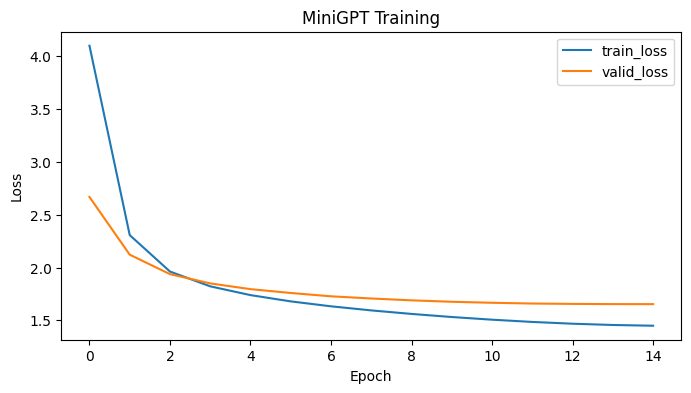

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["valid_loss"], label="valid_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MiniGPT Training")
plt.legend()
plt.show()

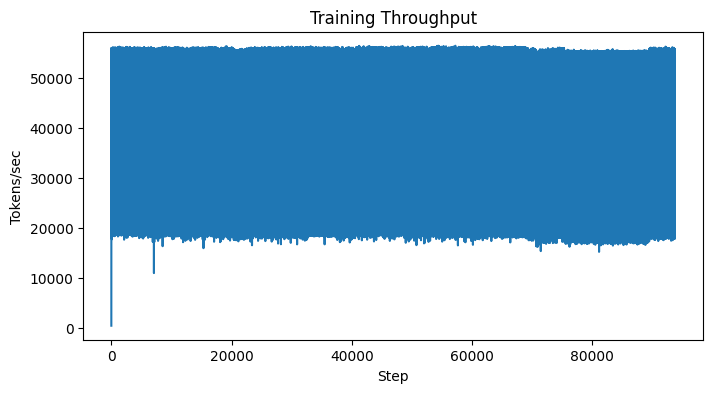

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(history["tokens_per_sec"])
plt.xlabel("Step")
plt.ylabel("Tokens/sec")
plt.title("Training Throughput")
plt.show()

## Test Generation

In [28]:
prompt = "Once upon a time in a quiet village"
print(generate_text(model, prompt, max_new_tokens=80, temperature=0.9, top_k=40))

Once upon a time in a quiet village lived two friends, Max and Jill. They loved to play hide and seek together. One day, they decided to play a game of hide-and-seek.

Max said, "Let's hide and fit in the well". Jill was very excited! They ran and hid behind the well.

But as their friends started to hide, they realized that no one would find them.


## Reload Checkpoint

In [29]:
# Example restore
restore_path = CHECKPOINT_DIR / "best_model"
ckptr = ocp.PyTreeCheckpointer()

restored_state = ckptr.restore(restore_path, item=nnx.state(model))
nnx.update(model, restored_state)

print("Checkpoint restored.")

/usr/local/lib/python3.12/dist-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:711: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Checkpoint restored.


## Model Persistance for Hugging Face

In [30]:
src_ckpt = CHECKPOINT_DIR / "best_model"
zip_base = "/kaggle/working/best_model_export"

archive_path = shutil.make_archive(zip_base, "zip", root_dir=src_ckpt)
print("Created archive:", archive_path)

Created archive: /kaggle/working/best_model_export.zip


In [31]:
EXPORT_DIR = Path("/kaggle/working/hf_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "max_len": int(MAX_LEN),
    "vocab_name": VOCAB_NAME,
    "vocab_size": int(VOCAB_SIZE),
    "embed_dim": int(EMBED_DIM),
    "num_heads": int(NUM_HEADS),
    "num_layers": int(NUM_LAYERS),
    "mlp_dim": int(MLP_DIM),
    "pad_id": int(PAD_ID),
    "eot_id": int(EOT_ID),
}

with open(EXPORT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:", EXPORT_DIR / "config.json")

Saved: /kaggle/working/hf_export/config.json
